# Finalisasi Model SVR/XGBoost per Parameter — Evaluasi pada 11 Subjek Kalibrasi

**Tanggal kegiatan: 5 September 2026**

Melengkapi `perbaikan_loso_5september.ipynb` (perbaikan skema validasi LOSO), notebook ini
menjalankan seleksi otomatis penuh (`api.vital_model_training.train_all`) pada seluruh 11 subjek
kalibrasi yang terkumpul sampai hari ini (setelah pengujian keenam menambah S010 dan S011), untuk
menghasilkan **konfigurasi model final** per parameter fisiologis dan mengevaluasi seberapa dekat
prediksinya terhadap nilai sebenarnya. Ini adalah finalisasi dari rangkaian evaluasi yang dimulai
pada 27 Agustus (`evaluasi_svr_xgboost_27agustus.ipynb`), 29 Agustus
(`konfigurasi_final_svr_xgboost_29agustus.ipynb`), dan 2 September
(`pengujian_5_retraining_2september.ipynb`).

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from api.vital_model_training import records_to_dataframe, train_all

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df_raw = pd.read_csv("../kalibrasi_semua.csv")
df_raw["session_ts"] = pd.to_datetime(df_raw["session_ts"], format="ISO8601")
df = records_to_dataframe(df_raw.to_dict("records"))

print(f"Data kalibrasi per 5 September 2026: {len(df)} baris, {df['subject_id'].nunique()} subjek unik")
print(f"Subjek: {sorted(df['subject_id'].unique())}")

Data kalibrasi per 5 September 2026: 11 baris, 11 subjek unik
Subjek: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011']


## 1. Konfigurasi model final per parameter

In [2]:
all_models, all_metrics = train_all(df)

tabel = pd.DataFrame([
    {
        "Parameter": m["label"], "Model terpilih": m["model_name"],
        "Set fitur": m["feature_set_name"], "R2": m["r2"], "MAE": m["mae"],
        "n_subjek": m["n_subjects"], "Keterandalan": m["reliability"],
    }
    for m in all_metrics.values()
])
print(tabel.to_string(index=False))
print()
for m in all_metrics.values():
    print(f"- {m['label']}: {m['reliability_note']}")

         Parameter       Model terpilih                 Set fitur      R2   MAE  n_subjek Keterandalan
Gula Darah (mg/dL) XGBoost (reg. ketat)       Minimal (usia saja) -0.1025 31.88        11        LEMAH
Kolesterol (mg/dL) XGBoost (reg. ketat)       Minimal (usia saja) -0.0392 24.79        11        LEMAH
 Asam Urat (mg/dL)            SVR (rbf) Serapan (IR/red DC, usia) -0.0009  0.76        11        LEMAH
   Sistolik (mmHg)         SVR (linear)           Penuh (7 fitur) -0.0809 13.87        11        LEMAH
  Diastolik (mmHg)         SVR (linear)           Penuh (7 fitur)  0.1343  8.21        11        LEMAH

- Gula Darah (mg/dL): 11 subjek - metrik masih sangat goyah. Target ≥30 subjek untuk angka yang bisa dipertanggungjawabkan.
- Kolesterol (mg/dL): 11 subjek - metrik masih sangat goyah. Target ≥30 subjek untuk angka yang bisa dipertanggungjawabkan.
- Asam Urat (mg/dL): 11 subjek - metrik masih sangat goyah. Target ≥30 subjek untuk angka yang bisa dipertanggungjawabkan.
- Sistolik

## 2. Prediksi vs nilai sebenarnya, per parameter (evaluasi LOSO)

Titik yang dekat garis diagonal berarti prediksi dekat nilai sebenarnya. Sebaran yang lebar adalah keterbatasan yang dilaporkan apa adanya, konsisten dengan status keterandalan di atas.

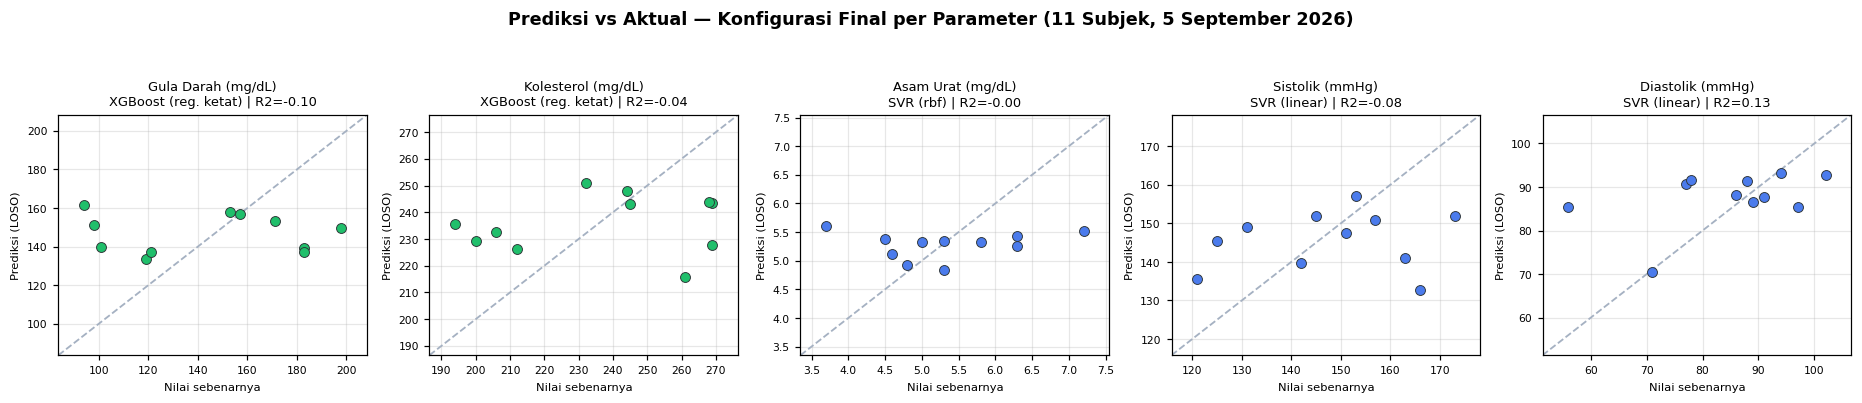

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
for ax, (target_col, m) in zip(axes, all_metrics.items()):
    y_true = np.array(m["cv_y_true"])
    y_pred = np.array(m["cv_y_pred"])
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    pad = (hi - lo) * 0.1 or 1
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="#a5b1c2", lw=1.2)
    warna = "#4b7bec" if m["model_name"].startswith("SVR") else (
        "#20bf6b" if m["model_name"].startswith("XGBoost") else "#eb3b5a")
    ax.scatter(y_true, y_pred, s=42, color=warna, edgecolor="#2d3436", linewidth=.6, zorder=3)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(f"{m['label']}\n{m['model_name']} | R2={m['r2']:.2f}", fontsize=8.5)
    ax.set_xlabel("Nilai sebenarnya", fontsize=7.5)
    ax.set_ylabel("Prediksi (LOSO)", fontsize=7.5)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=.3)

fig.suptitle("Prediksi vs Aktual — Konfigurasi Final per Parameter (11 Subjek, 5 September 2026)",
             fontsize=11.5, fontweight="bold", y=1.06)
plt.tight_layout()
plt.show()

## Kesimpulan

Dengan 11 subjek kalibrasi, seleksi otomatis menetapkan **SVR dan XGBoost sebagai pemenang pada
seluruh 5 parameter fisiologis** — Gula Darah dan Kolesterol dimenangkan XGBoost, sedangkan Asam
Urat, Sistolik, dan Diastolik dimenangkan SVR. MLP tidak menang pada satupun parameter, konsisten
dengan temuan sejak evaluasi 27 Agustus. Ini menjadi **konfigurasi resmi pengganti MLP** yang
dilaporkan pada Laporan Kemajuan.

Status keterandalan naik dari "TIDAK VALID" (n<10, pada evaluasi 16 Agustus–2 September) menjadi
**"LEMAH"** (10≤n<30) untuk seluruh parameter — masih jauh dari target ≥30 subjek yang disebut
`docs/pelatihan_model_estimasi_vital.md` agar metrik bisa dipertanggungjawabkan, sehingga angka R2
dan MAE di atas tetap dilaporkan sebagai keterbatasan, bukan capaian akhir.